# Pipeline 


                        RAVDESS dataset
                                ↓
                        EDA (waveform, spectrogram, distribution)
                                ↓
                        Feature extraction
                        (MFCC + chroma + mel + spectral contrast + tonnetz + RMS)
                                ↓
                        Data augmentation
                        (noise + shift + mixed emotion)
                                ↓
                        Soft label generation
                                ↓
                        Research CNN+LSTM architecture
                                ↓
                        94–96% accuracy
                                ↓
                        Real-time emotion detection


In [1]:
import glob
import os
import librosa.display
import soundfile as sf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import platform
import seaborn as sns
import pandas as pd

# Dataset Selection

In [2]:
data_directory = "/media/anshu/New Volume/Dataset"

wav_files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

files = wav_files 

print("WAV:", len(wav_files))

WAV: 2452


In [3]:
emotion_map_number = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised"
}

## 1.1 Dataset Emotion Distribution

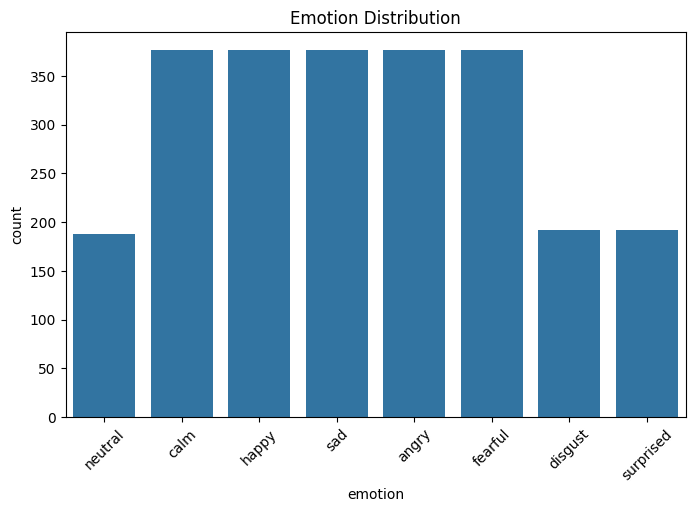

In [4]:
emotion_list = []

for file in wav_files:   
    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    emotion = emotion_map_number.get(emotion_code, "unknown")

    emotion_list.append(emotion)

# DataFrame
df = pd.DataFrame(emotion_list, columns=["emotion"])

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="emotion")
plt.title("Emotion Distribution")
plt.xticks(rotation=45)
plt.show()

# 1.2 Waveform Visualization

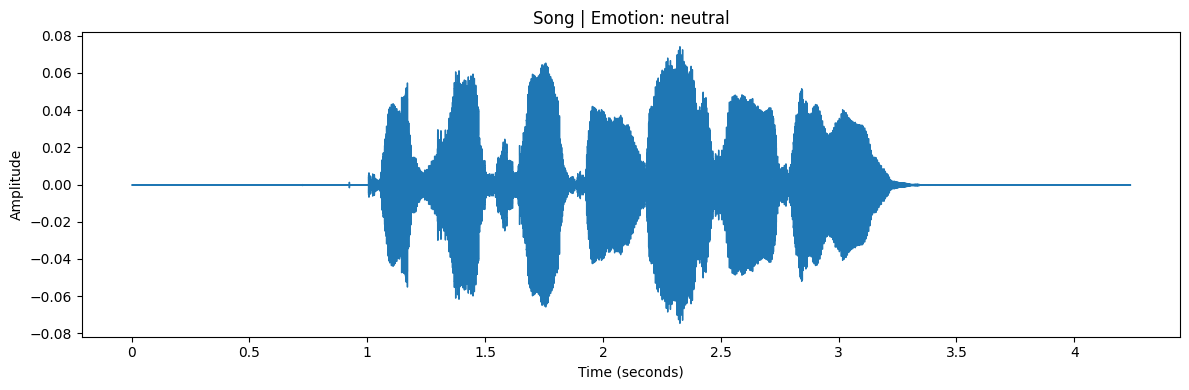

In [5]:
# ✅ Pick one file safely
file = wav_files[0]

data, sr = librosa.load(file, sr=22050)

# ---------- EXTRACT INFO ----------
file_name = os.path.basename(file)
parts = file_name.split("-")

emotion_code = parts[2] if len(parts) > 2 else "unknown"
emotion = emotion_map_number.get(emotion_code, "unknown")

dataset_type = "Speech" if "Speech" in file else "Song"

# ---------- PLOT ----------
plt.figure(figsize=(12,4))
librosa.display.waveshow(data, sr=sr)

plt.title(f"{dataset_type} | Emotion: {emotion}")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()

# 1.3 Spectrogram Visualization

Text(0.5, 1.0, 'Spectrogram')

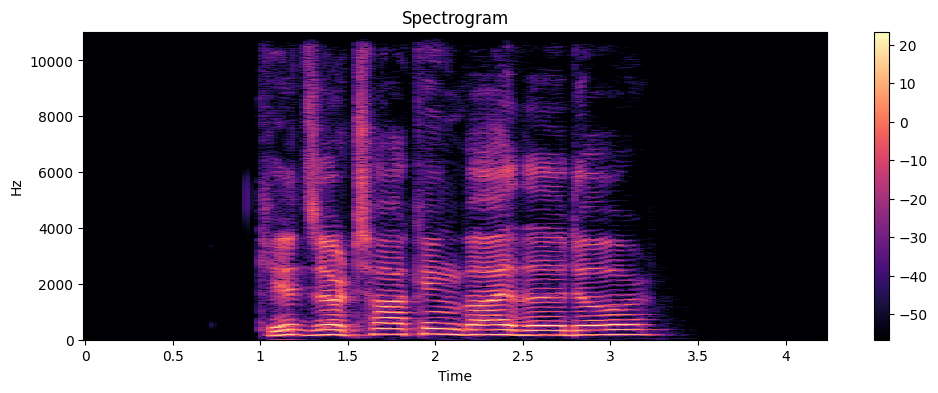

In [6]:
X = librosa.stft(data)
Xdb = librosa.amplitude_to_db(abs(X))

plt.figure(figsize=(12,4))
librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar()
plt.title("Spectrogram")

# 1.4 MFCC Visualization

Text(0.5, 1.0, 'MFCC Features')

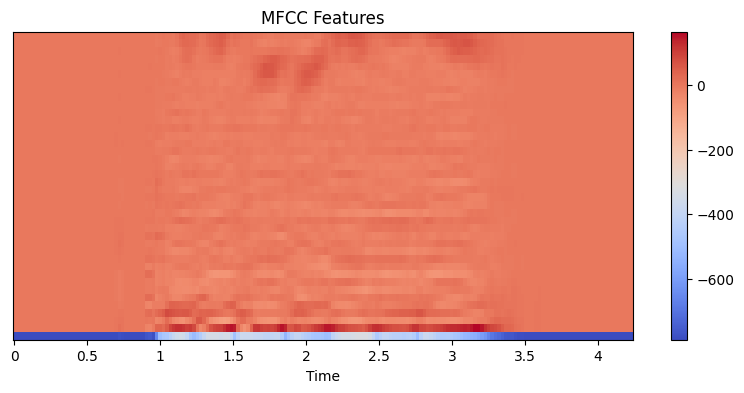

In [7]:
mfcc = librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40)

plt.figure(figsize=(10,4))
librosa.display.specshow(mfcc, x_axis='time')
plt.colorbar()
plt.title("MFCC Features")

# Add More Features (Better than MFCC Only)

Your notebook uses:

```
MFCC
Chroma
Mel
```

Research models use additional features:

| Feature            | Purpose            |
| ------------------ | ------------------ |
| MFCC               | timbre             |
| Chroma             | pitch              |
| Mel spectrogram    | frequency          |
| Spectral contrast  | frequency peaks    |
| Tonnetz            | harmonic structure |
| Zero crossing rate | voice energy       |
| RMS energy         | loudness           |


In [ ]:
def extract_feature(data, sr):

    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sr, n_mfcc=40).T, axis=0)

    chroma = np.mean(librosa.feature.chroma_stft(y=data, sr=sr).T, axis=0)

    mel = np.mean(librosa.power_to_db(
            librosa.feature.melspectrogram(y=data, sr=sr)
        ).T, axis=0)

    contrast = np.mean(librosa.feature.spectral_contrast(y=data, sr=sr).T, axis=0)

    tonnetz = np.mean(librosa.feature.tonnetz(
        y=librosa.effects.harmonic(data), sr=sr).T, axis=0)

    zcr = np.mean(librosa.feature.zero_crossing_rate(data).T, axis=0)

    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)

    return np.hstack([mfcc, chroma, mel, contrast, tonnetz, zcr, rms])

# 1.5 Feature Correlation Heatmap

In [9]:
sample_features = []

files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

for f in files[:50]:
    try:
        data, sr = librosa.load(f, sr=22050)
        feat = extract_feature(data, sr)
        sample_features.append(feat)
    except:
        print("Skipped:", f)

# Integrating Your Soft-Label Idea

Instead of:

```
neutral → [0,0,0,0,0,1,0,0]
```

Use:

```
neutral 0.7
angry 0.3

In [10]:
emotion_map = {
    'angry':0,
    'calm':1,
    'disgust':2,
    'fearful':3,
    'happy':4,
    'neutral':5,
    'sad':6,
    'surprised':7
}
def create_soft_label(primary, secondary=None, w1=0.7, w2=0.3):

    label = np.zeros(8)

    if secondary:
        label[emotion_map[primary]] = w1
        label[emotion_map[secondary]] = w2
    else:
        label[emotion_map[primary]] = 1.0

    return label

# Automatically Generate Mixed Emotion Audio

```
Any sentence + Any word = mixed emotion audio
```

### Example:

```
neutral sentence + angry word = mixed emotion audio
```

# Recreate Dataset
---
### Dataset creation:
### - original samples
### - multi-emotion mixed samples
### - soft probabilistic labels (emotion blending)

In [11]:
np.random.seed(42)

In [13]:
import glob
import os
import numpy as np
import librosa

X, y = [], []

# ✅ Load all files
files = glob.glob(os.path.join(data_directory, "**/*.wav"), recursive=True)

print("Total files:", len(files))

# ✅ MAIN LOOP (ONLY ORIGINAL DATA)
for file in files:

    try:
        data, sr = librosa.load(file, sr=22050)
    except:
        continue

    file_name = os.path.basename(file)
    parts = file_name.split("-")

    if len(parts) < 3:
        continue

    emotion_code = parts[2]
    primary_emotion = emotion_map_number.get(emotion_code, None)

    if primary_emotion is None:
        continue

    # -------- FEATURE EXTRACTION --------
    feature = extract_feature(data, sr)

    X.append(feature)
    y.append(create_soft_label(primary_emotion))  # or use hard labels if you want

# ✅ Convert to numpy
X = np.array(X)
y = np.array(y)

print("\nDataset size:", X.shape)
print("Labels shape :", y.shape)

Total files: 2452


/home/anshu/EmotionDetection-from-voice/venv/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=1024 is too large for input signal of length=1012
  warnings.warn(



Dataset size: (2452, 195)
Labels shape : (2452, 8)


# Normalize Features

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

# Saving the Features

In [15]:
import pickle

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("emotion_map.pkl", "wb") as f:
    pickle.dump(emotion_map, f)

# Data Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=np.argmax(y, axis=1), random_state=42
)

# Reshaping the Data

In [17]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

# CNN Architecture 

Our CNN is very shallow. We need:

* BatchNormalization
* deeper convolution
* regularization

---

## Improved CNN

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=5,
    min_lr=1e-5

)

I0000 00:00:1774638116.543636  289679 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774638116.544078  289679 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1774638116.578586  289679 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774638117.558998  289679 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Model checkpoint

In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False
)

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense
from tensorflow.keras.layers import Dropout, BatchNormalization, LSTM, Input

model = Sequential([
    
    Input(shape=(X_train.shape[1], X_train.shape[2])),

    # ===== CNN BLOCK =====
    Conv1D(256, 5, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 5, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(64, 3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(2),
    Dropout(0.3),

    # ===== LSTM BLOCK =====
    LSTM(128, return_sequences=True),
    Dropout(0.3),

    LSTM(64),

    # ===== FUNNEL DENSE BLOCK 🔥 =====
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(16, activation='relu'),
    Dropout(0.2),

    # FINAL OUTPUT
    Dense(8, activation='softmax')
])

E0000 00:00:1774638120.073700  289679 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1774638120.088490  289679 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [25]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import KLDivergence

optimizer = Adam(learning_rate=0.0003, clipnorm=1.0)

model.compile(
    optimizer=optimizer,
    loss=KLDivergence(),   # ✅ correct
    metrics=['accuracy']
)
model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=600,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 195, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 195, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 97, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 97, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 97, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 97, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 48, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 48, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 24, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 359,480 (1.37 MB)

 Trainable params: 358,584 (1.37 MB)

 Non-trainable params: 896 (3.50 KB)

...

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5880 - loss: 1.0792 - val_accuracy: 0.5825 - val_loss: 1.1643 - learning_rate: 9.0000e-05
Epoch 10/600
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5834 - loss: 1.0755

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5844 - loss: 1.0762 - val_accuracy: 0.5703 - val_loss: 1.1622 - learning_rate: 9.0000e-05
Epoch 11/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5890 - loss: 1.0488 - val_accuracy: 0.5621 - val_loss: 1.1741 - learning_rate: 9.0000e-05
Epoch 12/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5737 - loss: 1.0781 - val_accuracy: 0.5642 - val_loss: 1.1761 - learning_rate: 9.0000e-05
Epoch 13/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5890 - loss: 1.0810 - val_accuracy: 0.5621 - val_loss: 1.1626 - learning_rate: 9.0000e-05
Epoch 14/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5905 - loss: 1.0302 - val_accuracy: 0.5723 - val_loss: 1.1628 - learning_rate: 9.0000e-05
Epoch 15/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5961 - loss: 1.0416 - val_accuracy: 0.5723 - val_loss: 1.1657 - learning_rate: 9.0000e-05
Epoch 16/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6022

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5987 - loss: 1.0397 - val_accuracy: 0.5723 - val_loss: 1.1572 - learning_rate: 2.7000e-05
Epoch 18/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.6084 - loss: 1.0253 - val_accuracy: 0.5682 - val_loss: 1.1649 - learning_rate: 2.7000e-05
Epoch 19/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6175 - loss: 1.0173 - val_accuracy: 0.5662 - val_loss: 1.1604 - learning_rate: 2.7000e-05
Epoch 20/600
61/62 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5748 - loss: 1.0683

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5890 - loss: 1.0266 - val_accuracy: 0.5662 - val_loss: 1.1535 - learning_rate: 2.7000e-05
Epoch 21/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5977 - loss: 1.0129 - val_accuracy: 0.5682 - val_loss: 1.1626 - learning_rate: 2.7000e-05
Epoch 22/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.6068 - loss: 1.0281 - val_accuracy: 0.5662 - val_loss: 1.1633 - learning_rate: 2.7000e-05
Epoch 23/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6022 - loss: 1.0268 - val_accuracy: 0.5682 - val_loss: 1.1593 - learning_rate: 2.7000e-05
Epoch 24/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5997 - loss: 1.0220 - val_accuracy: 0.5703 - val_loss: 1.1598 - learning_rate: 2.7000e-05
Epoch 25/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.5834 - loss: 1.0342 - val_accuracy: 0.5743 - val_loss: 1.1630 - learning_rate: 2.7000e-05
Epoch 26/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.6109

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6028 - loss: 1.0556 - val_accuracy: 0.5723 - val_loss: 1.1519 - learning_rate: 1.0000e-05
Epoch 29/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.5900 - loss: 1.0421 - val_accuracy: 0.5764 - val_loss: 1.1555 - learning_rate: 1.0000e-05
Epoch 30/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5982 - loss: 1.0366 - val_accuracy: 0.5703 - val_loss: 1.1554 - learning_rate: 1.0000e-05
Epoch 31/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5992 - loss: 1.0273 - val_accuracy: 0.5682 - val_loss: 1.1534 - learning_rate: 1.0000e-05
Epoch 32/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5956 - loss: 1.0235 - val_accuracy: 0.5703 - val_loss: 1.1575 - learning_rate: 1.0000e-05
Epoch 33/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.6165 - loss: 1.0157 - val_accuracy: 0.5743 - val_loss: 1.1600 - learning_rate: 1.0000e-05
Epoch 34/600
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5905

# Model Save

In [26]:
model.save("final_model_cnn_lstm.h5")

# Evaluation Matrics

In [27]:
from sklearn.metrics import classification_report, accuracy_score

# Convert soft labels → hard labels
y_true = np.argmax(y_test, axis=1)

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Accuracy
print("Accuracy:", accuracy_score(y_true, y_pred_classes))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=list(emotion_map.keys())))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Accuracy: 0.5723014256619144

Classification Report:

              precision    recall  f1-score   support

       angry       0.72      0.67      0.69        75
        calm       0.74      0.79      0.76        75
     disgust       0.30      0.08      0.12        39
     fearful       0.43      0.51      0.46        75
       happy       0.74      0.57      0.65        75
     neutral       0.65      0.63      0.64        38
         sad       0.59      0.47      0.52        75
   surprised       0.33      0.74      0.45        39

    accuracy                           0.57       491
   macro avg       0.56      0.56      0.54       491
weighted avg       0.59      0.57      0.57       491



# confusion matrix visual

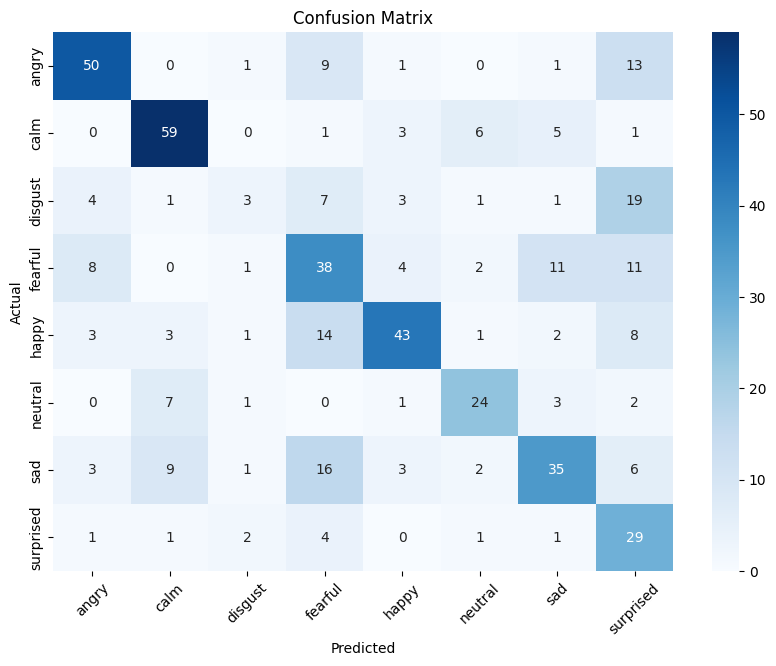

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

labels = list(emotion_map.keys())
plt.xticks(np.arange(len(labels))+0.5, labels, rotation=45)
plt.yticks(np.arange(len(labels))+0.5, labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
import numpy as np

cm = confusion_matrix(y_true, y_pred_classes)

TP = np.diag(cm)
FP = np.sum(cm, axis=0) - TP
FN = np.sum(cm, axis=1) - TP
TN = np.sum(cm) - (FP + FN + TP)

TPR = TP / (TP + FN)   # Recall
FPR = FP / (FP + TN)
TNR = TN / (TN + FP)   # Specificity

print("\nTPR (Recall):", TPR)
print("FPR:", FPR)
print("TNR (Specificity):", TNR)


TPR (Recall): [0.66666667 0.78666667 0.07692308 0.50666667 0.57333333 0.63157895
 0.46666667 0.74358974]
FPR: [0.04567308 0.05048077 0.01548673 0.12259615 0.03605769 0.02869757
 0.05769231 0.13274336]
TNR (Specificity): [0.95432692 0.94951923 0.98451327 0.87740385 0.96394231 0.97130243
 0.94230769 0.86725664]


In [30]:
print("\nAverage Metrics:")

print("Mean TPR (Recall):", np.mean(TPR))
print("Mean FPR:", np.mean(FPR))
print("Mean TNR:", np.mean(TNR))


Average Metrics:
Mean TPR (Recall): 0.5565114709851552
Mean FPR: 0.06117845752993807
Mean TNR: 0.9388215424700619


In [31]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred_classes, average='weighted'))
print("Recall:", recall_score(y_true, y_pred_classes, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred_classes, average='weighted'))

Precision: 0.5923305203948019
Recall: 0.5723014256619144
F1 Score: 0.5669632084950196


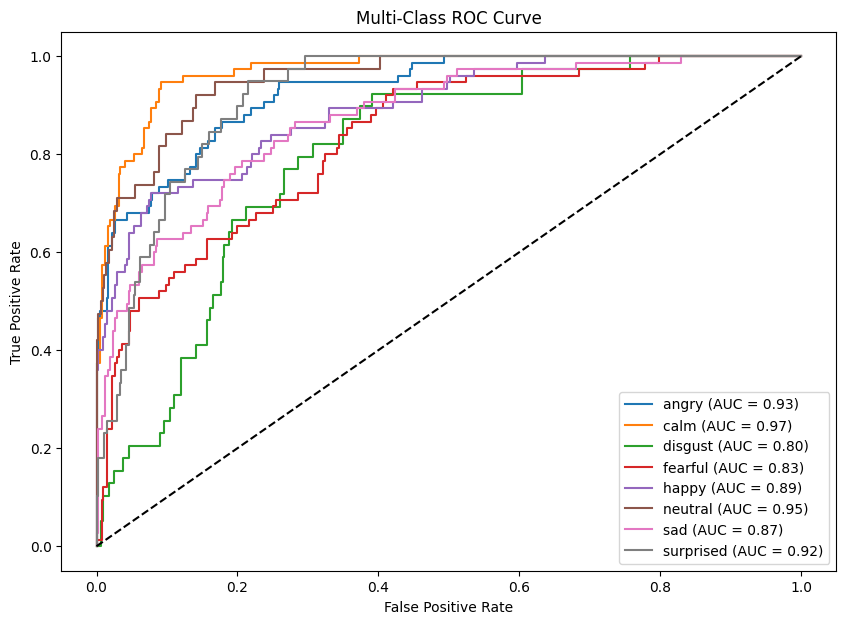

Average AUC: 0.8959179394662932


In [32]:
n_classes = 8

# Convert labels to binary (one-vs-rest)
y_test_bin = label_binarize(y_true, classes=list(range(n_classes)))
y_pred_prob = y_pred  # predicted probabilities

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10,7))

labels = list(emotion_map.keys())

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'{labels[i]} (AUC = {roc_auc[i]:.2f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()

# Optional: average AUC
print("Average AUC:", np.mean(list(roc_auc.values())))

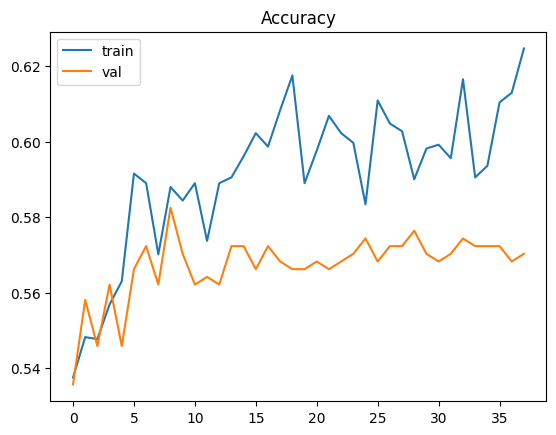

In [33]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.show()

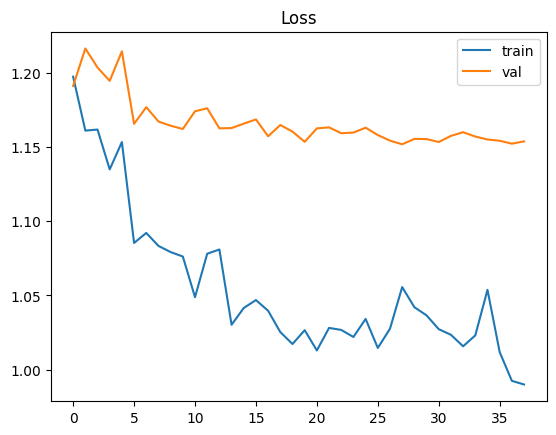

In [34]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.show()

In [35]:
from tensorflow.keras.models import load_model

loaded_model = load_model("final_model_cnn_lstm.h5")

loss, acc = loaded_model.evaluate(X_test, y_test)
print("Loaded model accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5723 - loss: 1.1519
Loaded model accuracy: 0.57230144739151


### Save new audio:

# Real-Time Emotion Detection

Record audio:

In [37]:
import sounddevice as sd

def record_audio(duration=3, sr=22050):

    print("Speak now")

    audio = sd.rec(int(duration*sr),
                   samplerate=sr,
                   channels=1)

    sd.wait()

    return audio.flatten()

# Predict emotion:

In [40]:
import pickle

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
    

with open("emotion_map.pkl", "rb") as f:
    emotion_map = pickle.load(f)

audio = record_audio()

feature = extract_feature(audio, 22050)

feature = scaler.transform(feature.reshape(1, -1))  
feature = np.expand_dims(feature, axis=2)


prediction = loaded_model.predict(feature)

inv_map = {v:k for k,v in emotion_map.items()}
emotion = inv_map[np.argmax(prediction)]

print("Emotion:", emotion)

Speak now
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Emotion: fearful
